# *SENTIMENT ANALYSIS FOR INDONESIAN POLTICIAL NEWS*
# this notebook using IndoBERT + BiLSTM model

# Import Library + define env & device

In [1]:
print("test")

test


In [2]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MinMaxScaler

from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports complete. Running on: {device}")

2026-05-27 02:21:58.756173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779848518.994057      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779848519.063348      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779848519.675710      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779848519.675751      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779848519.675754      58 computation_placer.cc:177] computation placer alr

✅ Imports complete. Running on: cuda


# Configuration & Hyperparameter defining

In [3]:
# --- Configuration ---
SEED = 42
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 512

# Paths
DATA_PATH = "/kaggle/input/datasets/davinraffilio9/datalabeled/data_labeled"
MODEL_PATH = "/kaggle/working"

# Sentiment Model Hyperparameters
LSTM_HIDDEN = 256
LSTM_LAYERS = 2
DROPOUT = 0.2


set_seed(SEED)

print(f"Model: IndoBERT + BiLSTM ({LSTM_LAYERS} layers, {LSTM_HIDDEN} hidden)")
print(f"Max Length: {MAX_LENGTH}")

Model: IndoBERT + BiLSTM (2 layers, 256 hidden)
Max Length: 512


# Data loading & integration

In [4]:
# Load Data
df1 = pd.read_csv(f"{DATA_PATH}/cnbc_labeled.csv")
df2 = pd.read_csv(f"{DATA_PATH}/detik_labeled.csv")
df3 = pd.read_csv(f"{DATA_PATH}/kompas_labeled.csv")

print(f"Detik: {len(df1)} | CNBC: {len(df2)} | Kompas: {len(df3)}")

# Combine Datasets
required_cols = ["date", "title", "content", "article_id", "text", "label"]

def _select_cols(df: pd.DataFrame) -> pd.DataFrame:
    return df[required_cols].copy()

df_seed = pd.concat(
    [_select_cols(df1), _select_cols(df2), _select_cols(df3)],
    ignore_index=True
)

print(f"Total Combined Samples: {len(df_seed)}")

Detik: 5343 | CNBC: 9999 | Kompas: 9980
Total Combined Samples: 25322


# EDA & data preprocessing

DATASET DISTRIBUTION (ORIGINAL)
Label Counts:
label
Neutral     14358
Positive     6172
Negative     4792
Name: count, dtype: int64


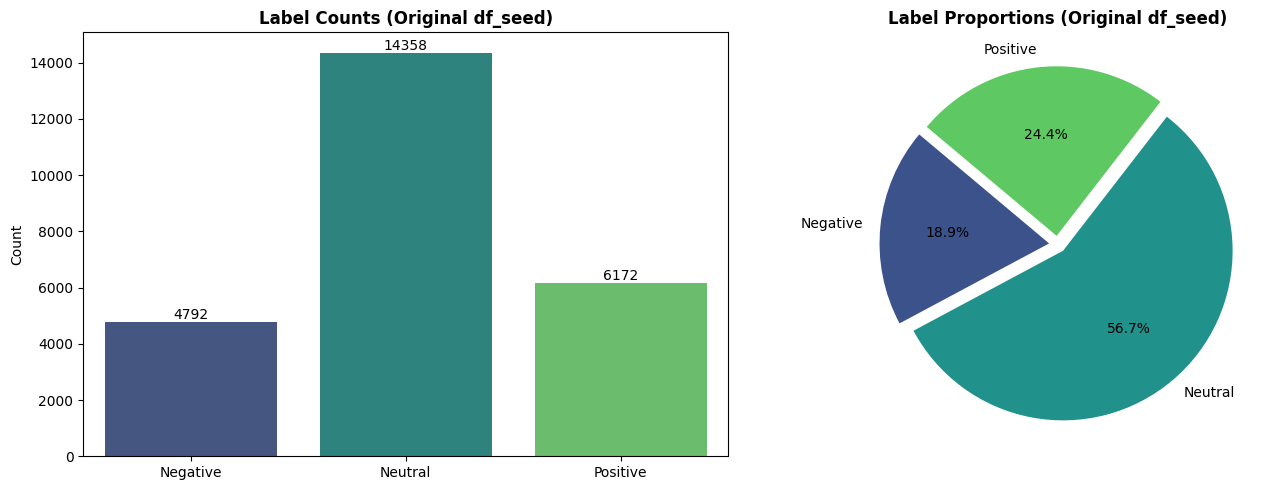


SPLITTING DATASET


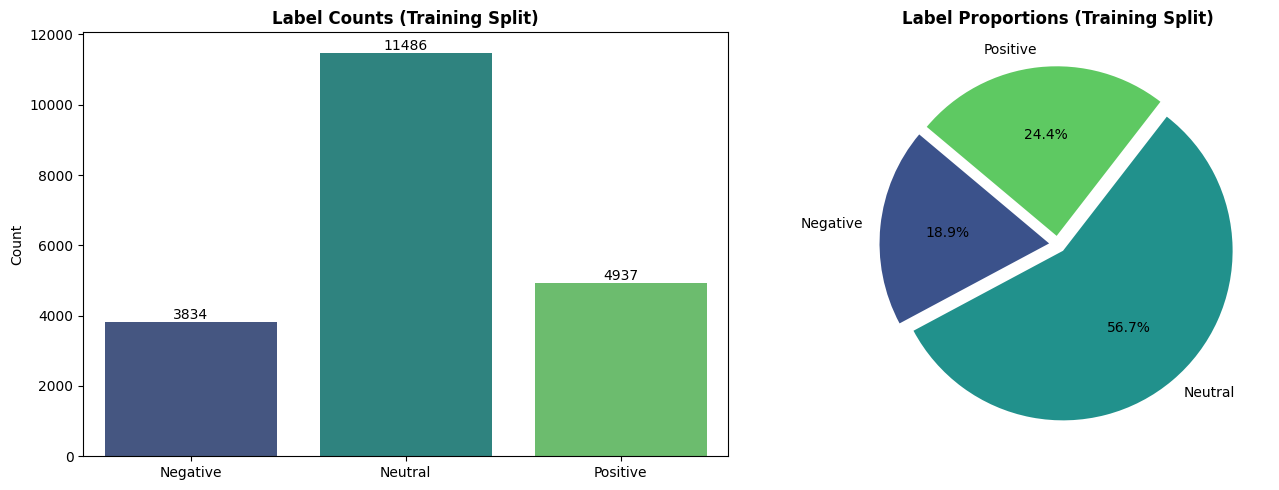


TRAINING CONFIGURATION
Train Size : 20257 samples
Val Size   : 5065 samples
------------------------------
Computed Class Weights (for Loss Function):
  Negative  : 2.6418
  Neutral   : 0.5879
  Positive  : 2.0515


In [5]:

# --- 0. Setup Visualization Function ---
def plot_label_distribution(df, target_col='label', title_suffix=''):
    """
    Creates a bar plot and pie chart for label distribution.
    Auto-detects if labels are original (-1,0,1) or mapped (0,1,2).
    """
    viz_df = df.copy()
    
    # Auto-detect label format
    unique_labels = set(viz_df[target_col].unique())
    if unique_labels.issubset({0, 1, 2}):
        label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'} # Mapped ID
    else:
        label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'} # Original Label
        
    viz_df['label_name'] = viz_df[target_col].map(label_map)
    order = ['Negative', 'Neutral', 'Positive']
    
    # Setup plot grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Bar Chart (Frequency)
    sns.countplot(x='label_name', data=viz_df, order=order, palette='viridis', ax=ax1)
    ax1.set_title(f'Label Counts {title_suffix}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    
    # Add numbers on top of bars
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black')

    # 2. Pie Chart (Proportion)
    counts = viz_df['label_name'].value_counts().reindex(order)
    ax2.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
            colors=sns.color_palette('viridis', 3), explode=(0.05, 0.05, 0.05))
    ax2.set_title(f'Label Proportions {title_suffix}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# --- 1. Check & Visualize Distribution (Original Data) ---
print("="*50)
print("DATASET DISTRIBUTION (ORIGINAL)")
print("="*50)

# Text Output
print("Label Counts:")
print(df_seed['label'].map({-1:'Negative', 0:'Neutral', 1:'Positive'}).value_counts())

# Diagram Output
plot_label_distribution(df_seed, target_col='label', title_suffix='(Original df_seed)')


# --- 2. Train/Val Split ---
print("\n" + "="*50)
print("SPLITTING DATASET")
print("="*50)

train_df, val_df = train_test_split(
    df_seed,
    test_size=0.2,
    stratify=df_seed['label'],
    random_state=SEED
)

# Visualize Train Split to confirm Stratification
plot_label_distribution(train_df, target_col='label', title_suffix='(Training Split)')


# --- 3. Remap Labels (-1, 0, 1 -> 0, 1, 2) ---
label_to_id = {-1: 0, 0: 1, 1: 2}
id_to_label = {0: "negative", 1: "neutral", 2: "positive"}

train_df['label_id'] = train_df['label'].map(label_to_id)
val_df['label_id'] = val_df['label'].map(label_to_id)


# --- 4. Compute Class Weights ---
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)

# Amplify minority class weights (Custom Adjustment)
# Logic: Give more focus to Negative/Positive, less to Neutral
class_weights = class_weights * np.array([1.5, 1.0, 1.5])
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)
print(f"Train Size : {len(train_df)} samples")
print(f"Val Size   : {len(val_df)} samples")
print("-" * 30)
print("Computed Class Weights (for Loss Function):")
for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
    print(f"  {label:<10}: {class_weights[i]:.4f}")

# Tokenization & dataset prep

In [6]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False, # Padding handled by collator later
            return_tensors=None
        )
        
        return {
            'input_ids': encoding['input_ids'],
            'attention_mask': encoding['attention_mask'],
            'labels': label
        }

# Create Dataset Objects
train_dataset = SentimentDataset(train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, MAX_LENGTH)
val_dataset = SentimentDataset(val_df['text'].tolist(), val_df['label_id'].tolist(), tokenizer, MAX_LENGTH)

print("✅ Dataset and Tokenizer ready.")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Dataset and Tokenizer ready.


# Model architecture definition (BiLSTM)

In [7]:
class IndoBertBiLSTM(nn.Module):
    def __init__(self, model_name, num_labels=3, lstm_hidden=256, lstm_layers=2, dropout=0.2, id_to_label=None, label_to_id=None):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.config = self.bert.config
        self.config.num_labels = num_labels
        
        if id_to_label:
            self.config.id2label = id_to_label
            self.config.label2id = label_to_id

        self.lstm = nn.LSTM(
            input_size=self.config.hidden_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state

        # Pack sequence for LSTM
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.lstm(packed)

        # Concat forward and backward hidden states
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        h = self.dropout(h)
        logits = self.classifier(h)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(loss=loss, logits=logits)

# Customize trainer & metrics

In [8]:
class FocalLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.focal_gamma = focal_gamma
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        ce_loss = F.cross_entropy(logits, labels, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
        
        return (focal_loss, outputs) if return_outputs else focal_loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    
    f1_per_class = f1_score(labels, preds, average=None)
    
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
    }

# Training initialization

In [9]:
# 1. Initialize Model
sentiment_model = IndoBertBiLSTM(
    model_name=MODEL_NAME,
    lstm_hidden=LSTM_HIDDEN,
    lstm_layers=LSTM_LAYERS,
    dropout=DROPOUT,
    id_to_label=id_to_label,
    label_to_id=label_to_id
).to(device)

# 2. Training Arguments
training_args = TrainingArguments(
    output_dir=f"{MODEL_PATH}/sentiment_training",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=1,
    learning_rate=3e-5,
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_dir=f"{MODEL_PATH}/logs",
    logging_steps=50,
    report_to="none",
    fp16=True,
    dataloader_num_workers=2,
    seed=SEED,
)

# 3. Initialize Trainer
trainer = FocalLossTrainer(
    class_weights=class_weights_tensor,
    focal_gamma=2.0,
    model=sentiment_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer Initialized.")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

✅ Trainer Initialized.


# Execute training

In [10]:
print("="*40)
print("🚀 STARTING TRAINING")
print("="*40)

trainer.train()

print("✅ Training Complete.")

🚀 STARTING TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,F1 Negative,F1 Neutral,F1 Positive
1,0.747500,0.356383,0.468904,0.465021,0.382149,0.543860,0.221950,0.629253
2,0.514400,0.293473,0.550049,0.568149,0.505398,0.717949,0.399339,0.587160
3,0.361800,0.204914,0.652122,0.660090,0.633483,0.689291,0.582708,0.708271
4,0.289300,0.222578,0.671273,0.677700,0.657995,0.677026,0.616616,0.739459
5,0.199400,0.278124,0.792498,0.789022,0.793895,0.757849,0.798826,0.810390
6,0.128400,0.297953,0.806318,0.802140,0.807242,0.784587,0.814956,0.806876
7,0.090100,0.351003,0.791905,0.789524,0.792705,0.785479,0.798682,0.784410
8,0.054100,0.372227,0.795854,0.793174,0.796810,0.790698,0.804005,0.784819
9,0.032000,0.516123,0.818756,0.811476,0.819706,0.794319,0.834036,0.806072
10,0.015800,0.592100,0.824284,0.815128,0.824962,0.795086,0.842162,0.808137


✅ Training Complete.


# Final evaluation

In [11]:
print("Running Final Evaluation...")

# Predict
pred = trainer.predict(val_dataset)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

# Metrics
final_metrics = trainer.evaluate()

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Accuracy    : {final_metrics['eval_accuracy']:.4f}")
print(f"Macro F1    : {final_metrics['eval_macro_f1']:.4f}")
print(f"Weighted F1 : {final_metrics['eval_weighted_f1']:.4f}")
print("-" * 50)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["negative", "neutral", "positive"], digits=4))

Running Final Evaluation...



FINAL RESULTS
Accuracy    : 0.8294
Macro F1    : 0.8199
Weighted F1 : 0.8300
--------------------------------------------------

Classification Report:

              precision    recall  f1-score   support

    negative     0.7716    0.8288    0.7992       958
     neutral     0.8685    0.8276    0.8476      2872
    positive     0.7929    0.8340    0.8129      1235

    accuracy                         0.8294      5065
   macro avg     0.8110    0.8302    0.8199      5065
weighted avg     0.8317    0.8294    0.8300      5065



# analysis evaluation

In [ ]:
!pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 6.3 MB/s eta 0:00:00


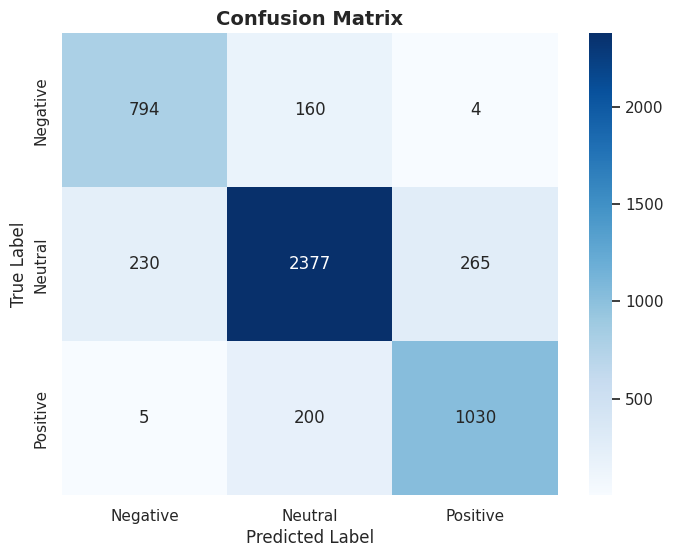

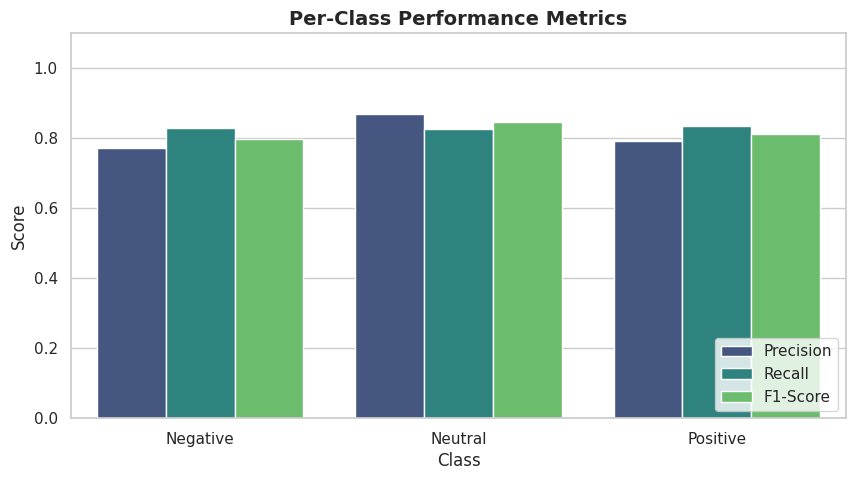


MOST FREQUENT WORDS BY SENTIMENT


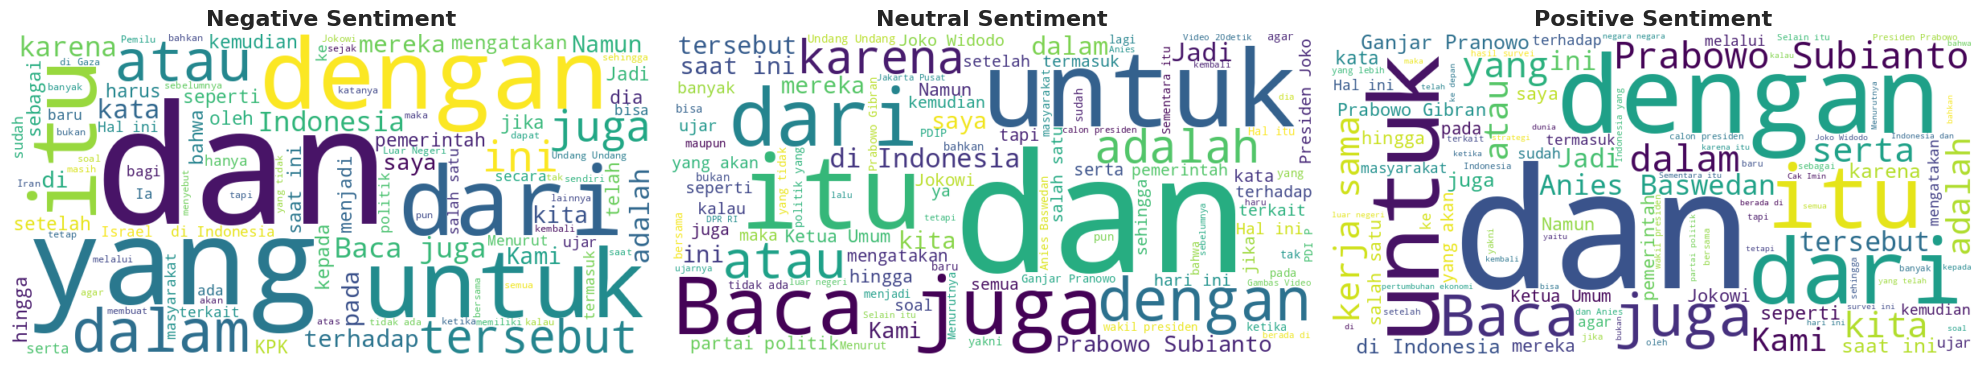


MOST FREQUENT WORDS BY SENTIMENT (CLEANED)


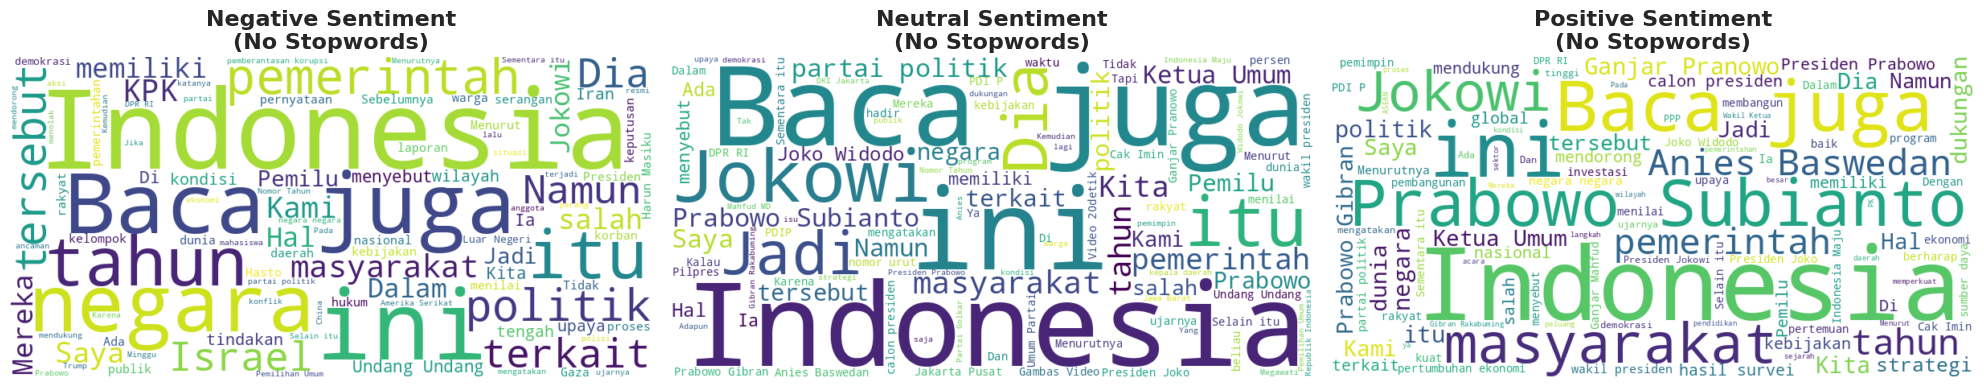

In [ ]:
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
# Pastikan style plot rapi
sns.set(style="whitegrid")

def plot_evaluation_results(y_true, y_pred, df_val):
    """
    Menampilkan Confusion Matrix, Grafik Metrik, dan Word Cloud.
    """
    target_names = ["Negative", "Neutral", "Positive"]
    
    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

    # --- 2. Per-Class Metrics Visualization (Precision, Recall, F1) ---
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    metrics_df = pd.DataFrame({
        'Class': target_names * 3,
        'Score': np.concatenate([precision, recall, f1]),
        'Metric': ['Precision']*3 + ['Recall']*3 + ['F1-Score']*3
    })
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df, palette='viridis')
    plt.title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.show()

    # --- 3. Word Clouds per Sentiment ---
    print("\n" + "="*50)
    print("MOST FREQUENT WORDS BY SENTIMENT")
    print("="*50)
    
    # Mapping label ID ke nama untuk filtering
    # Pastikan 'val_df' memiliki kolom 'text' dan 'label_id'
    # Kita menggunakan data validasi (df_val)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label_name in enumerate(target_names):
        # Ambil teks dari data validasi yang label aslinya = i
        # Menggunakan kolom 'text' dari val_df
        subset_text = " ".join(df_val[df_val['label_id'] == i]['text'].astype(str).tolist())
        
        if not subset_text:
            subset_text = "No Data" # Handle jika kosong
            
        wc = WordCloud(width=800, height=400, background_color='white', 
                       colormap='viridis', max_words=100).generate(subset_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{label_name} Sentiment', fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

    # --- 3. Word Clouds per Sentiment (With Sastrawi Stopword Removal) ---
    print("\n" + "="*50)
    print("MOST FREQUENT WORDS BY SENTIMENT (CLEANED)")
    print("="*50)
    
    # 1. Inisialisasi Sastrawi StopWord Remover
    factory = StopWordRemoverFactory()
    stopword_remover = factory.create_stop_word_remover()
    
    # Mapping target_names jika belum didefinisikan di luar fungsi
    target_names = ["Negative", "Neutral", "Positive"]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label_name in enumerate(target_names):
        # Ambil teks dari data validasi yang label aslinya = i (0, 1, 2)
        # Menggunakan kolom 'text' dari df_val sesuai struktur dataset kita
        raw_subset_text = " ".join(df_val[df_val['label_id'] == i]['text'].astype(str).tolist())
        
        if raw_subset_text:
            # 2. Terapkan Stopword Removal dari Sastrawi
            # Proses ini akan menghilangkan kata umum bahasa Indonesia
            cleaned_text = stopword_remover.remove(raw_subset_text)
        else:
            cleaned_text = "No Data"
            
        # 3. Generate WordCloud dari teks yang sudah bersih
        wc = WordCloud(
            width=800, 
            height=400, 
            background_color='white', 
            colormap='viridis', 
            max_words=100
        ).generate(cleaned_text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{label_name} Sentiment\n(No Stopwords)', fontsize=16, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# --- EKSEKUSI VISUALISASI ---
# Pastikan val_df tersedia dari cell sebelumnya
plot_evaluation_results(y_true, y_pred, val_df)

# save model

In [ ]:
import os
import torch
import json

# Tentukan direktori penyimpanan
SAVE_DIR = f"{MODEL_PATH}/final_indobert_bilstm_model"
os.makedirs(SAVE_DIR, exist_ok=True)

print("="*50)
print("💾 SAVING FINAL MODEL & TOKENIZER")
print("="*50)

# 1. Simpan bobot model custom (State Dict PyTorch)
model_save_path = os.path.join(SAVE_DIR, "pytorch_model.bin")
torch.save(sentiment_model.state_dict(), model_save_path)
print(f"✔️ Model weights saved to: {model_save_path}")

# 2. Simpan Tokenizer (Bawaan Hugging Face)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✔️ Tokenizer saved to: {SAVE_DIR}")

# 3. Simpan Config & Label Mapping (Buat mempermudah inference)
label_mapping = {
    "id2label": id_to_label,
    "label2id": label_to_id,
    "max_length": MAX_LENGTH,
    "lstm_hidden": LSTM_HIDDEN,
    "lstm_layers": LSTM_LAYERS,
    "dropout": DROPOUT
}

with open(os.path.join(SAVE_DIR, "model_config.json"), "w") as f:
    json.dump(label_mapping, f, indent=4)
print(f"✔️ Model config & label mapping saved to: {os.path.join(SAVE_DIR, 'model_config.json')}")

print("\n✅ Proses save model selesai!")

💾 SAVING FINAL MODEL & TOKENIZER
✔️ Model weights saved to: /kaggle/working/final_indobert_bilstm_model/pytorch_model.bin
✔️ Tokenizer saved to: /kaggle/working/final_indobert_bilstm_model
✔️ Model config & label mapping saved to: /kaggle/working/final_indobert_bilstm_model/model_config.json

✅ Proses save model selesai!


# Ablation Study (R10 - Reviewer Response)
## Comparing CLS vs Mean Pooling + Hidden Size Variants

In [ ]:
# ================================================================
# ABLATION STUDY 1: CLS vs Mean Pooling Strategy
# Menjawab Review 10: ablation study yang diminta reviewer
# Referensi: Devlin et al. (2019) BERT paper - penggunaan [CLS] token
# ================================================================

print("="*60)
print("ABLATION STUDY 1: POOLING STRATEGY")
print("CLS token vs Mean Pooling on IndoBERT output")
print("="*60)

class IndoBertBiLSTM_Ablation(nn.Module):
    """
    Extended BiLSTM model supporting two pooling strategies:
    - 'cls'  : hanya menggunakan [CLS] token (default & paper setting)
    - 'mean' : rata-rata semua token (mean pooling, masked)
    
    Referensi pooling:
    Reimers & Gurevych (2019), "Sentence-BERT", EMNLP 2019.
    https://arxiv.org/abs/1908.10084
    """
    def __init__(self, model_name, num_labels=3, lstm_hidden=256,
                 lstm_layers=2, dropout=0.2, pooling='cls'):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.config = self.bert.config
        self.pooling = pooling

        self.lstm = nn.LSTM(
            input_size=self.config.hidden_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)
        self.num_labels = num_labels

    def mean_pool(self, last_hidden, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        summed = (last_hidden * mask).sum(dim=1)
        count  = mask.sum(dim=1).clamp(min=1e-9)
        return summed / count

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq = out.last_hidden_state                  # (B, T, 768)

        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        packed  = nn.utils.rnn.pack_padded_sequence(seq, lengths,
                      batch_first=True, enforce_sorted=False)
        packed_out, (h_n, _) = self.lstm(packed)

        if self.pooling == 'cls':
            h = torch.cat([h_n[-2], h_n[-1]], dim=1)   # last fwd+bwd hidden
        else:  # mean over ALL lstm outputs
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
            mask = attention_mask[:, :lstm_out.size(1)].unsqueeze(-1).float()
            h = (lstm_out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

        h = self.dropout(h)
        logits = self.classifier(h)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
        return SequenceClassifierOutput(loss=loss, logits=logits)


def quick_train_eval(pooling_strategy, epochs=5, lr=3e-5):
    """
    Train mini version (5 epochs) for ablation comparison.
    Full 15-epoch run is done on the final chosen config only.
    """
    model = IndoBertBiLSTM_Ablation(
        model_name=MODEL_NAME,
        lstm_hidden=LSTM_HIDDEN,
        lstm_layers=LSTM_LAYERS,
        dropout=DROPOUT,
        pooling=pooling_strategy
    ).to(device)

    args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/ablation_{pooling_strategy}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        num_train_epochs=epochs,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        fp16=True,
        report_to="none",
        seed=SEED,
    )

    trainer_abl = FocalLossTrainer(
        class_weights=class_weights_tensor,
        focal_gamma=2.0,
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer_abl.train()
    res = trainer_abl.evaluate()
    pred_out = trainer_abl.predict(val_dataset)
    y_p = np.argmax(pred_out.predictions, axis=1)
    y_t = pred_out.label_ids
    report = classification_report(y_t, y_p,
                 target_names=["Negative", "Neutral", "Positive"],
                 digits=4, output_dict=True)
    return res, report

print("\n--- Training CLS pooling (5 epochs) ---")
res_cls, rep_cls = quick_train_eval('cls')

print("\n--- Training Mean pooling (5 epochs) ---")
res_mean, rep_mean = quick_train_eval('mean')

# ---- Summary Table ----
print("\n" + "="*60)
print("ABLATION RESULT: POOLING STRATEGY")
print("{:<15} {:>10} {:>12} {:>12}".format("Pooling","Accuracy","Macro F1","Weighted F1"))
print("-"*52)
for name, r in [("CLS (paper)", res_cls), ("Mean", res_mean)]:
    print("{:<15} {:>10.4f} {:>12.4f} {:>12.4f}".format(
        name,
        r['eval_accuracy'],
        r['eval_macro_f1'],
        r['eval_weighted_f1']
    ))

print("\nPer-class F1 Comparison:")
print("{:<15} {:>12} {:>12} {:>12}".format("","Negative","Neutral","Positive"))
for name, rep in [("CLS (paper)", rep_cls), ("Mean", rep_mean)]:
    print("{:<15} {:>12.4f} {:>12.4f} {:>12.4f}".format(
        name,
        rep['Negative']['f1-score'],
        rep['Neutral']['f1-score'],
        rep['Positive']['f1-score']
    ))


## Ablation Study 2: Focal Loss Gamma Variants (R10)

In [ ]:
# ================================================================
# ABLATION STUDY 2: Focal Loss Gamma Parameter
# gamma=0 is equivalent to standard CrossEntropy
# Referensi: Lin et al. (2020), "Focal Loss for Dense Object Detection"
# IEEE TPAMI 42(2):318-327. https://doi.org/10.1109/TPAMI.2020.2992413
# ================================================================

print("="*60)
print("ABLATION STUDY 2: FOCAL LOSS GAMMA")
print("gamma=0 (CE), gamma=1.0, gamma=2.0 (paper), gamma=3.0")
print("="*60)

gamma_results = {}

for gamma_val in [0.0, 1.0, 2.0, 3.0]:
    print(f"\n--- gamma={gamma_val} ---")
    base_model = IndoBertBiLSTM(
        model_name=MODEL_NAME,
        lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS,
        dropout=DROPOUT, id_to_label=id_to_label, label_to_id=label_to_id
    ).to(device)

    args_g = TrainingArguments(
        output_dir=f"{MODEL_PATH}/ablation_gamma{gamma_val}",
        eval_strategy="epoch", save_strategy="no",
        learning_rate=3e-5, num_train_epochs=5,
        per_device_train_batch_size=4, gradient_accumulation_steps=4,
        weight_decay=0.01, lr_scheduler_type="cosine",
        warmup_ratio=0.1, fp16=True, report_to="none", seed=SEED,
    )
    t_g = FocalLossTrainer(
        class_weights=class_weights_tensor, focal_gamma=gamma_val,
        model=base_model, args=args_g,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    t_g.train()
    res_g = t_g.evaluate()
    pred_g = t_g.predict(val_dataset)
    y_p_g = np.argmax(pred_g.predictions, axis=1)
    gamma_results[gamma_val] = {
        'eval': res_g,
        'report': classification_report(
            pred_g.label_ids, y_p_g,
            target_names=["Negative","Neutral","Positive"],
            digits=4, output_dict=True)
    }

# ---- Summary ----
print("\n" + "="*60)
print("ABLATION: FOCAL LOSS GAMMA")
print("{:<10} {:>10} {:>12} {:>10} {:>10}".format(
    "Gamma","Accuracy","Macro F1","F1-Neg","F1-Pos"))
print("-"*55)
for g, data in gamma_results.items():
    r = data['eval']; rep = data['report']
    lbl = f"{g:.1f}" + (" (paper)" if g==2.0 else "")
    print("{:<10} {:>10.4f} {:>12.4f} {:>10.4f} {:>10.4f}".format(
        lbl,
        r['eval_accuracy'], r['eval_macro_f1'],
        rep['Negative']['f1-score'], rep['Positive']['f1-score']
    ))


## Ablation Study 3: BiLSTM Hidden Size (R10)

In [ ]:
# ================================================================
# ABLATION STUDY 3: BiLSTM Hidden Size
# Menjawab pertanyaan reviewer tentang pemilihan hyperparameter
# Referensi: Shidik et al. (2024) - BiLSTM NER Bahasa Indonesia
# ================================================================

print("="*60)
print("ABLATION STUDY 3: BILSTM HIDDEN SIZE")
print("Comparing hidden=128, 256 (paper), 384")
print("="*60)

hidden_results = {}

for h_size in [128, 256, 384]:
    print(f"\n--- hidden_size={h_size} ---")
    model_h = IndoBertBiLSTM(
        model_name=MODEL_NAME,
        lstm_hidden=h_size, lstm_layers=LSTM_LAYERS,
        dropout=DROPOUT, id_to_label=id_to_label, label_to_id=label_to_id
    ).to(device)

    args_h = TrainingArguments(
        output_dir=f"{MODEL_PATH}/ablation_hidden{h_size}",
        eval_strategy="epoch", save_strategy="no",
        learning_rate=3e-5, num_train_epochs=5,
        per_device_train_batch_size=4, gradient_accumulation_steps=4,
        weight_decay=0.01, lr_scheduler_type="cosine",
        warmup_ratio=0.1, fp16=True, report_to="none", seed=SEED,
    )
    t_h = FocalLossTrainer(
        class_weights=class_weights_tensor, focal_gamma=2.0,
        model=model_h, args=args_h,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    t_h.train()
    res_h = t_h.evaluate()
    pred_h = t_h.predict(val_dataset)
    y_p_h = np.argmax(pred_h.predictions, axis=1)
    hidden_results[h_size] = {
        'eval': res_h,
        'report': classification_report(
            pred_h.label_ids, y_p_h,
            target_names=["Negative","Neutral","Positive"],
            digits=4, output_dict=True)
    }

print("\n" + "="*60)
print("ABLATION: HIDDEN SIZE")
print("{:<12} {:>10} {:>12} {:>10} {:>10}".format(
    "Hidden","Accuracy","Macro F1","F1-Neg","F1-Pos"))
print("-"*57)
for h, data in hidden_results.items():
    r = data['eval']; rep = data['report']
    lbl = f"{h}" + (" (paper)" if h==256 else "")
    print("{:<12} {:>10.4f} {:>12.4f} {:>10.4f} {:>10.4f}".format(
        lbl, r['eval_accuracy'], r['eval_macro_f1'],
        rep['Negative']['f1-score'], rep['Positive']['f1-score']
    ))


# K-Fold Cross-Validation (R2, R8 - Reviewer Response)
## Membuktikan stabilitas hasil bukan artefak satu split

In [ ]:
# ================================================================
# STRATIFIED K-FOLD CROSS-VALIDATION (k=5)
# Menjawab Review 2: dataset kecil, risiko overfitting
# Menjawab Review 8: kurangnya analisis statistik
#
# Referensi:
# Stone (1974), Cross-validatory choice and assessment of 
# statistical predictions. J. Royal Statistical Society 36(2).
# Kohavi (1995), A study of cross-validation and bootstrap for
# accuracy estimation and model selection. IJCAI-95.
# ================================================================

from sklearn.model_selection import StratifiedKFold
import copy

print("="*60)
print("STRATIFIED 5-FOLD CROSS-VALIDATION")
print("Memvalidasi stabilitas model BiLSTM")
print("="*60)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
X_all = df_seed['text'].values
y_all = df_seed['label'].map(label_to_id).values  # mapped labels 0,1,2

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
    print(f"\n{'='*40}")
    print(f"FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*40}")

    fold_train_texts = X_all[train_idx].tolist()
    fold_val_texts   = X_all[val_idx].tolist()
    fold_train_labels = y_all[train_idx].tolist()
    fold_val_labels   = y_all[val_idx].tolist()

    # Class weights per fold
    fold_cw = compute_class_weight('balanced',
                  classes=np.unique(fold_train_labels),
                  y=fold_train_labels)
    fold_cw = fold_cw * np.array([1.5, 1.0, 1.5])
    fold_cw_tensor = torch.FloatTensor(fold_cw).to(device)

    fold_train_ds = SentimentDataset(fold_train_texts, fold_train_labels, tokenizer, MAX_LENGTH)
    fold_val_ds   = SentimentDataset(fold_val_texts,   fold_val_labels,   tokenizer, MAX_LENGTH)

    fold_model = IndoBertBiLSTM(
        model_name=MODEL_NAME,
        lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS, dropout=DROPOUT,
        id_to_label=id_to_label, label_to_id=label_to_id
    ).to(device)

    fold_args = TrainingArguments(
        output_dir=f"{MODEL_PATH}/fold_{fold+1}",
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="macro_f1",
        save_total_limit=1,
        learning_rate=3e-5, num_train_epochs=15,
        per_device_train_batch_size=4, gradient_accumulation_steps=4,
        weight_decay=0.01, lr_scheduler_type="cosine",
        warmup_ratio=0.1, fp16=True, report_to="none", seed=SEED,
    )

    fold_trainer = FocalLossTrainer(
        class_weights=fold_cw_tensor, focal_gamma=2.0,
        model=fold_model, args=fold_args,
        train_dataset=fold_train_ds, eval_dataset=fold_val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
    fold_trainer.train()

    pred_fold = fold_trainer.predict(fold_val_ds)
    y_t_f = pred_fold.label_ids
    y_p_f = np.argmax(pred_fold.predictions, axis=1)

    fold_report = classification_report(
        y_t_f, y_p_f,
        target_names=["Negative","Neutral","Positive"],
        digits=4, output_dict=True)

    fold_results.append({
        'fold': fold+1,
        'accuracy':    accuracy_score(y_t_f, y_p_f),
        'macro_f1':    f1_score(y_t_f, y_p_f, average='macro'),
        'weighted_f1': f1_score(y_t_f, y_p_f, average='weighted'),
        'f1_neg': fold_report['Negative']['f1-score'],
        'f1_neu': fold_report['Neutral']['f1-score'],
        'f1_pos': fold_report['Positive']['f1-score'],
    })
    print(f"Fold {fold+1} -> Macro F1: {fold_results[-1]['macro_f1']:.4f}")

# ---- Summary Statistics ----
print("\n" + "="*70)
print("CROSS-VALIDATION SUMMARY (5-Fold)")
print("{:<8} {:>10} {:>12} {:>12} {:>10} {:>10}".format(
    "Fold","Accuracy","Macro F1","Weighted F1","F1-Neg","F1-Pos"))
print("-"*65)
for r in fold_results:
    print("{:<8} {:>10.4f} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}".format(
        r['fold'], r['accuracy'], r['macro_f1'], r['weighted_f1'],
        r['f1_neg'], r['f1_pos']))

# Statistical Summary
metrics_kf = ['accuracy','macro_f1','weighted_f1','f1_neg','f1_neu','f1_pos']
print("\n" + "-"*65)
print("MEAN ± STD (across 5 folds):")
for m in metrics_kf:
    vals = [r[m] for r in fold_results]
    print(f"  {m:<15}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n📌 Catatan untuk paper:")
print("   Laporkan mean ± std di Section IV sebagai bukti")
print("   kestabilan model (tidak overfitting pada satu split).")


# Explainable AI - SHAP Analysis (R8 - Reviewer Response)
## Interpretability: fitur mana yang paling mempengaruhi prediksi

In [ ]:
# ================================================================
# EXPLAINABLE AI: INTEGRATED GRADIENTS (Captum)
# Karena model adalah neural network (bukan tree), SHAP TreeExplainer
# tidak applicable. Gunakan Captum (PyTorch-native).
#
# Referensi:
# Sundararajan et al. (2017), "Axiomatic Attribution for Deep Networks"
# ICML 2017. https://arxiv.org/abs/1703.01365
#
# Ribeiro et al. (2016), "Why Should I Trust You?": Explaining the
# Predictions of Any Classifier. KDD 2016.
# https://arxiv.org/abs/1602.04938
# ================================================================

print("Installing captum for Integrated Gradients (XAI)...")
import subprocess
subprocess.run(["pip", "install", "captum", "-q"])

from captum.attr import LayerIntegratedGradients
import torch

print("\n" + "="*60)
print("EXPLAINABLE AI: INTEGRATED GRADIENTS")
print("Menjelaskan prediksi model per-token")
print("="*60)

# Pastikan model sudah terlatih (pakai 'sentiment_model' dari training utama)
sentiment_model.eval()

def predict_fn(input_ids):
    """Wrapper untuk Captum: input token IDs -> logits."""
    mask = (input_ids != tokenizer.pad_token_id).long()
    with torch.no_grad():
        out = sentiment_model(input_ids=input_ids, attention_mask=mask)
    return out.logits

# Pilih 3 contoh representatif: 1 per kelas
examples = {}
for class_id, class_name in id_to_label.items():
    # Ambil sampel pertama dari val_df kelas ini
    subset = val_df[val_df['label_id'] == class_id]
    if len(subset) == 0:
        continue
    sample_text = subset.iloc[0]['text']
    examples[class_name] = sample_text

lig = LayerIntegratedGradients(
    lambda input_ids: predict_fn(input_ids),
    sentiment_model.bert.embeddings.word_embeddings
)

xai_results = {}
for class_name, text in examples.items():
    enc = tokenizer(text, return_tensors='pt',
                    truncation=True, max_length=MAX_LENGTH,
                    padding=True).to(device)
    input_ids = enc['input_ids']
    baseline  = torch.zeros_like(input_ids)

    pred_logit = predict_fn(input_ids)
    pred_class = pred_logit.argmax(-1).item()

    attributions, delta = lig.attribute(
        input_ids,
        baselines=baseline,
        target=pred_class,
        n_steps=50,
        return_convergence_delta=True
    )

    # Aggregate attribution per token (L2 norm across embedding dim)
    attr_sum = attributions.squeeze(0).norm(dim=-1).detach().cpu().numpy()
    tokens   = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().tolist())

    # Top-10 most influential tokens
    top_idx = np.argsort(attr_sum)[::-1][:10]
    top_tokens = [(tokens[i], float(attr_sum[i])) for i in top_idx
                  if tokens[i] not in ['[CLS]','[SEP]','[PAD]']][:10]

    xai_results[class_name] = {
        'predicted': id_to_label[pred_class],
        'top_tokens': top_tokens
    }

    print(f"\n--- Contoh '{class_name}' (prediksi: {id_to_label[pred_class]}) ---")
    print(f"Teks: {text[:120]}...")
    print("Top influential tokens:")
    for tok, score in top_tokens:
        bar = '█' * int(score * 50 / (top_tokens[0][1] + 1e-9))
        print(f"  {tok:<20} {score:.4f}  {bar}")

# ---- Visualisasi ----
fig, axes = plt.subplots(1, len(xai_results), figsize=(18, 5))
if len(xai_results) == 1:
    axes = [axes]

for ax, (cls_name, data) in zip(axes, xai_results.items()):
    tokens_plot = [t for t, _ in data['top_tokens']]
    scores_plot = [s for _, s in data['top_tokens']]
    
    colors = plt.cm.RdYlGn(np.array(scores_plot) / max(scores_plot + [1e-9]))
    bars = ax.barh(range(len(tokens_plot)), scores_plot, color=colors)
    ax.set_yticks(range(len(tokens_plot)))
    ax.set_yticklabels(tokens_plot, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{cls_name}\n(pred: {data["predicted"]})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Attribution Score')

plt.suptitle('Integrated Gradients: Top Influential Tokens per Sentiment Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/xai_integrated_gradients.png", bbox_inches='tight', dpi=150)
plt.show()
print("\n✅ XAI visualization saved.")


# Computational Efficiency Analysis (R8 - Reviewer Response)
## Mengukur inference time dan memory footprint

In [ ]:
# ================================================================
# STATISTICAL SIGNIFICANCE TESTING
# Menjawab Review 8: absence of statistical significance analysis
#
# Metode:
# 1. McNemar's test: membandingkan BiLSTM vs GRU (paired predictions)
# 2. Bootstrap Confidence Interval untuk Macro F1
#
# Referensi:
# McNemar (1947), Note on the sampling error of the difference between
# correlated proportions, Psychometrika 12(2):153-157.
#
# Dror et al. (2018), The Hitchhiker's Guide to Testing Statistical
# Significance in NLP. ACL 2018.
# https://aclanthology.org/P18-1128/
#
# Efron & Tibshirani (1993), An Introduction to the Bootstrap. CRC Press.
# ================================================================

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import mcnemar

print("="*60)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*60)

# ---- 1. Bootstrap CI untuk Macro F1 (model utama) ----
N_BOOTSTRAP = 1000
np.random.seed(SEED)

# Gunakan prediksi final dari model BiLSTM utama
bootstrap_f1 = []
n_val = len(y_true)

for _ in range(N_BOOTSTRAP):
    boot_idx = np.random.choice(n_val, size=n_val, replace=True)
    boot_f1  = f1_score(y_true[boot_idx], y_pred[boot_idx], average='macro')
    bootstrap_f1.append(boot_f1)

ci_low  = np.percentile(bootstrap_f1, 2.5)
ci_high = np.percentile(bootstrap_f1, 97.5)

print("\n--- Bootstrap Confidence Interval (Macro F1) ---")
print(f"   Model   : IndoBERT + BiLSTM")
print(f"   Macro F1: {np.mean(bootstrap_f1):.4f}")
print(f"   95% CI  : [{ci_low:.4f}, {ci_high:.4f}]")

# Visualisasi bootstrap distribution
plt.figure(figsize=(8, 4))
plt.hist(bootstrap_f1, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(np.mean(bootstrap_f1), color='red',    linestyle='--',
            label=f'Mean={np.mean(bootstrap_f1):.4f}')
plt.axvline(ci_low,  color='orange', linestyle='--',
            label=f'95% CI [{ci_low:.4f}, {ci_high:.4f}]')
plt.axvline(ci_high, color='orange', linestyle='--')
plt.xlabel('Macro F1-Score')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of Macro F1 (n=1000 iterations)')
plt.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/bootstrap_ci.png", dpi=150)
plt.show()

# ---- 2. McNemar's Test (BiLSTM vs referensi GRU dari paper) ----
print("\n--- McNemar's Test: BiLSTM vs GRU ---")
print("(Memerlukan prediksi GRU; jalankan notebook GRU terlebih dahulu")
print(" dan load hasil prediksi, atau gunakan hasil dari kode ini)")
print()

# Ilustrasi format McNemar (ganti gru_preds dengan array aktual)
# Di sini kita buat dummy sebagai template; isi dengan pred GRU nyata
try:
    gru_preds_path = f"{MODEL_PATH}/gru_val_preds.npy"
    y_pred_gru = np.load(gru_preds_path)

    correct_bilstm = (y_pred == y_true)
    correct_gru    = (y_pred_gru == y_true)

    b = np.sum( correct_bilstm & ~correct_gru)  # BiLSTM correct, GRU wrong
    c = np.sum(~correct_bilstm &  correct_gru)  # BiLSTM wrong,   GRU correct

    table = np.array([[0, b], [c, 0]])  # McNemar contingency
    result = mcnemar(table, exact=False, correction=True)
    print(f"   Discordant pairs: b={b}, c={c}")
    print(f"   Chi-square statistic: {result.statistic:.4f}")
    print(f"   p-value: {result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print("   ✅ Difference is statistically significant (p < 0.05)")
    else:
        print("   ⚠️  No statistically significant difference (p >= 0.05)")
except FileNotFoundError:
    print("   [SKIP] GRU predictions not found.")
    print("   Simpan prediksi GRU: np.save('gru_val_preds.npy', y_pred_gru)")
    print("   lalu jalankan sel ini kembali.")

print("\n📌 Tambahkan nilai CI dan p-value ke Section IV.D (Statistical Analysis)")


# Save Final Predictions (untuk cross-model significance test)

In [ ]:
# ================================================================
# Simpan prediksi final BiLSTM untuk dipakai di McNemar's test
# ketika membandingkan dengan model lain (GRU, CNN, dll)
# ================================================================
import numpy as np

np.save(f"{MODEL_PATH}/bilstm_val_preds.npy", y_pred)
np.save(f"{MODEL_PATH}/bilstm_val_true.npy",  y_true)

print(f"✅ BiLSTM predictions saved:")
print(f"   {MODEL_PATH}/bilstm_val_preds.npy  -> shape {y_pred.shape}")
print(f"   {MODEL_PATH}/bilstm_val_true.npy   -> shape {y_true.shape}")
print()
print("Gunakan file ini di notebook GRU/CNN untuk McNemar's test.")
